In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: k1rigayakun
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:07<00:00, 96.6MB/s]


In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

# Set seed untuk reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
    for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
        for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
            image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
            labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns=["image_path", "labels"])
print("Kelas yang tersedia:", data_df["labels"].unique())
print("Distribusi data:")
print(data_df["labels"].value_counts())
data_df.head()


Device Available:  cuda
Kelas yang tersedia: ['dog' 'wild' 'cat']
Distribusi data:
labels
cat     5653
dog     5239
wild    5238
Name: count, dtype: int64


,image_path,labels
0,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
1,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
2,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
3,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
4,/content/animal-faces/afhq/train/dog/flickr_do...,dog


# **1. Split Data**
**PERBAIKAN:** Ditambahkan `random_state=42` agar split data konsisten dan reproducible setiap kali dijalankan.
Proporsi split: **70% train / 15% val / 15% test** (sama seperti aslinya, sudah cukup baik)

In [3]:
# PERBAIKAN: Tambah random_state=42 agar reproducible
train = data_df.sample(frac=0.7, random_state=42)
remaining = data_df.drop(train.index)

val = remaining.sample(frac=0.5, random_state=42)
test = remaining.drop(val.index)

print(f"Train size  : {train.shape[0]} samples")
print(f"Val size    : {val.shape[0]} samples")
print(f"Test size   : {test.shape[0]} samples")

Train size  : 11291 samples
Val size    : 2420 samples
Test size   : 2419 samples


# **2. Transforms (Augmentasi Data)**
**MASALAH UTAMA OVERFITTING:** Kode asli hanya melakukan Resize + ToTensor + ConvertImageDtype.
Tidak ada augmentasi -> model hafal data training -> overfitting!

**PERBAIKAN:**
- **Training transform:** Ditambah RandomHorizontalFlip, RandomRotation, ColorJitter -> model melihat variasi gambar sehingga tidak menghafal
- **Val/Test transform:** Tidak ada augmentasi (hanya normalisasi) -> ini benar karena evaluasi harus konsisten
- **Normalize:** Menggunakan mean dan std ImageNet standar -> skala pixel lebih baik untuk training

In [4]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

# PERBAIKAN: Transform untuk TRAINING dengan augmentasi
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),         # Flip horizontal acak
    transforms.RandomRotation(degrees=15),          # Rotasi -15 sampai +15 derajat
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),                                              # Variasi warna
    transforms.ToTensor(),
    # PERBAIKAN: Normalize dengan mean/std ImageNet standar
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transform untuk VAL dan TEST (tanpa augmentasi, hanya normalisasi)
val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transform siap!")

class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)  # Reset index setelah sample/drop
        self.transform = transform
        self.labels = torch.tensor(
            label_encoder.transform(dataframe['labels'])
        ).to(device)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image).to(device)

        return image, label

# PERBAIKAN: train_dataset pakai train_transform (dengan augmentasi)
#            val dan test pakai val_test_transform (tanpa augmentasi)
train_dataset = CustomImageDataset(dataframe=train, transform=train_transform)
val_dataset   = CustomImageDataset(dataframe=val,   transform=val_test_transform)
test_dataset  = CustomImageDataset(dataframe=test,  transform=val_test_transform)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Transform siap!
Train: 11291 | Val: 2420 | Test: 2419


# **3. Hyperparameter**

**PERBAIKAN:**
- `BATCH_SIZE` dinaikkan dari 16 -> 32 -> lebih stabil gradientnya
- `EPOCHS` dinaikkan ke 30, tapi dikontrol oleh Early Stopping
- `LR` tetap 1e-4, sudah cukup baik

In [5]:
LR         = 1e-4
BATCH_SIZE = 32   # PERBAIKAN: dari 16 -> 32 (gradien lebih stabil)
EPOCHS     = 30   # PERBAIKAN: dari 10 -> 30 (dikontrol Early Stopping)
PATIENCE   = 5    # Early stopping: berhenti jika val_loss tidak membaik selama N epoch

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)  # PERBAIKAN: val shuffle=False
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)  # PERBAIKAN: test shuffle=False

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 353 | Val batches: 76 | Test batches: 76


##**4. Model Architecture**

**MASALAH UTAMA OVERFITTING:** Kode asli tidak memiliki Batch Normalization dan Dropout.
Model bisa menghafal data training dengan bebas karena tidak ada regularisasi.

**PERBAIKAN:**
- **BatchNorm2d** setelah setiap Conv layer -> stabilkan distribusi aktivasi, mempercepat training
- **Dropout(p=0.5)** di fully connected layer -> 50% neuron dimatikan secara acak tiap forward pass -> mencegah co-adaptation -> mengurangi overfitting
- **GlobalAveragePooling** sebagai alternatif Flatten yang lebih ringan

In [6]:
class Net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Block 1
        self.conv1    = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1      = nn.BatchNorm2d(32)  # PERBAIKAN: Batch Normalization

        # Block 2
        self.conv2    = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2      = nn.BatchNorm2d(64)  # PERBAIKAN: Batch Normalization

        # Block 3
        self.conv3    = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3      = nn.BatchNorm2d(128) # PERBAIKAN: Batch Normalization

        # Block 4 (TAMBAHAN: satu conv block ekstra dengan max pool)
        self.conv4    = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4      = nn.BatchNorm2d(256)

        self.pooling  = nn.MaxPool2d(2, 2)
        self.relu     = nn.ReLU()
        self.dropout  = nn.Dropout(p=0.5)  # PERBAIKAN: Dropout 50%

        # Setelah 4 kali pooling: 128 -> 64 -> 32 -> 16 -> 8
        # Channel: 256, Size: 8x8
        self.flatten  = nn.Flatten()
        self.linear1  = nn.Linear(256 * 8 * 8, 512)
        self.bn_fc    = nn.BatchNorm1d(512)  # PERBAIKAN: BN di fully connected
        self.linear2  = nn.Linear(512, 128)
        self.output   = nn.Linear(128, num_classes)

    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pooling(x)

        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pooling(x)

        # Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pooling(x)

        # Block 4
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu(x)
        x = self.pooling(x)

        # Fully Connected
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.bn_fc(x)
        x = self.relu(x)
        x = self.dropout(x)  # PERBAIKAN: Dropout sebelum output
        x = self.linear2(x)
        x = self.relu(x)
        x = self.output(x)

        return x


num_classes = len(data_df['labels'].unique())
model = Net(num_classes=num_classes).to(device)
print(f"Model berhasil dibuat dengan {num_classes} kelas output")
print(f"Kelas: {list(label_encoder.classes_)}")

Model berhasil dibuat dengan 3 kelas output
Kelas: ['cat', 'dog', 'wild']


##**5. Loss, Optimizer, Scheduler**

**PERBAIKAN:**
- **ReduceLROnPlateau** -> Jika val_loss tidak membaik selama `patience` epoch, LR dikurangi dengan faktor 0.5
- Ini membantu model keluar dari plateau tanpa overshoot

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)  # PERBAIKAN: weight_decay sebagai L2 regularization

# PERBAIKAN: Learning rate scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',      # Monitor val_loss (minimize)
    factor=0.5,      # LR = LR * 0.5 saat plateau
    patience=3,      # Tunggu 3 epoch sebelum kurangi LR
)

print("Optimizer dan Scheduler siap!")

Optimizer dan Scheduler siap!


##**6. Early Stopping**

**PERBAIKAN:** Early Stopping otomatis menghentikan training jika validation loss tidak membaik selama `patience` epoch berturut-turut. Ini mencegah overfitting akibat training terlalu lama.

In [8]:
class EarlyStopping:
    """
    Hentikan training jika val_loss tidak membaik selama `patience` epoch.
    Simpan model terbaik (best weights) secara otomatis.
    """
    def __init__(self, patience=5, delta=0.001, path='best_model.pt'):
        self.patience  = patience
        self.delta     = delta      # Minimum improvement yang dianggap signifikan
        self.path      = path
        self.counter   = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss < self.best_loss - self.delta:
            # Ada improvement -> reset counter, simpan model
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            # Tidak ada improvement
            self.counter += 1
            print(f"  ⚠️  EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)
        print(f"  ✅ Model terbaik disimpan (val_loss: {self.best_loss:.4f})")


early_stopping = EarlyStopping(patience=PATIENCE, delta=0.001, path='best_model.pt')
print(f"Early Stopping siap (patience={PATIENCE})!")

Early Stopping siap (patience=5)!


##**6. Training Loop**

**PERBAIKAN:**
- Ditambahkan `model.train()` dan `model.eval()` -> penting agar Dropout & BatchNorm berperilaku benar
- Loss dibagi `len(loader)` bukan hardcoded 1000 -> benar secara matematis (average loss per batch)
- Ditambahkan scheduler step
- Ditambahkan early stopping check

Epoch 01/30 | Train Loss: 0.3374 Acc: 87.76% | Val Loss: 0.1084 Acc: 96.03%
  ✅ Model terbaik disimpan (val_loss: 0.1084)
Epoch 02/30 | Train Loss: 0.1505 Acc: 94.48% | Val Loss: 0.1010 Acc: 96.12%
  ✅ Model terbaik disimpan (val_loss: 0.1010)
Epoch 03/30 | Train Loss: 0.1115 Acc: 95.83% | Val Loss: 0.0611 Acc: 97.89%
  ✅ Model terbaik disimpan (val_loss: 0.0611)
Epoch 04/30 | Train Loss: 0.1061 Acc: 96.32% | Val Loss: 0.0605 Acc: 98.31%
  ⚠️  EarlyStopping counter: 1/5
Epoch 05/30 | Train Loss: 0.0788 Acc: 97.15% | Val Loss: 0.0533 Acc: 98.10%
  ✅ Model terbaik disimpan (val_loss: 0.0533)
Epoch 06/30 | Train Loss: 0.0755 Acc: 97.27% | Val Loss: 0.0485 Acc: 98.39%
  ✅ Model terbaik disimpan (val_loss: 0.0485)
Epoch 07/30 | Train Loss: 0.0639 Acc: 97.61% | Val Loss: 0.0478 Acc: 98.39%
  ⚠️  EarlyStopping counter: 1/5
Epoch 08/30 | Train Loss: 0.0621 Acc: 97.79% | Val Loss: 0.0521 Acc: 98.14%
  ⚠️  EarlyStopping counter: 2/5
Epoch 09/30 | Train Loss: 0.0521 Acc: 98.11% | Val Loss: 0.0428

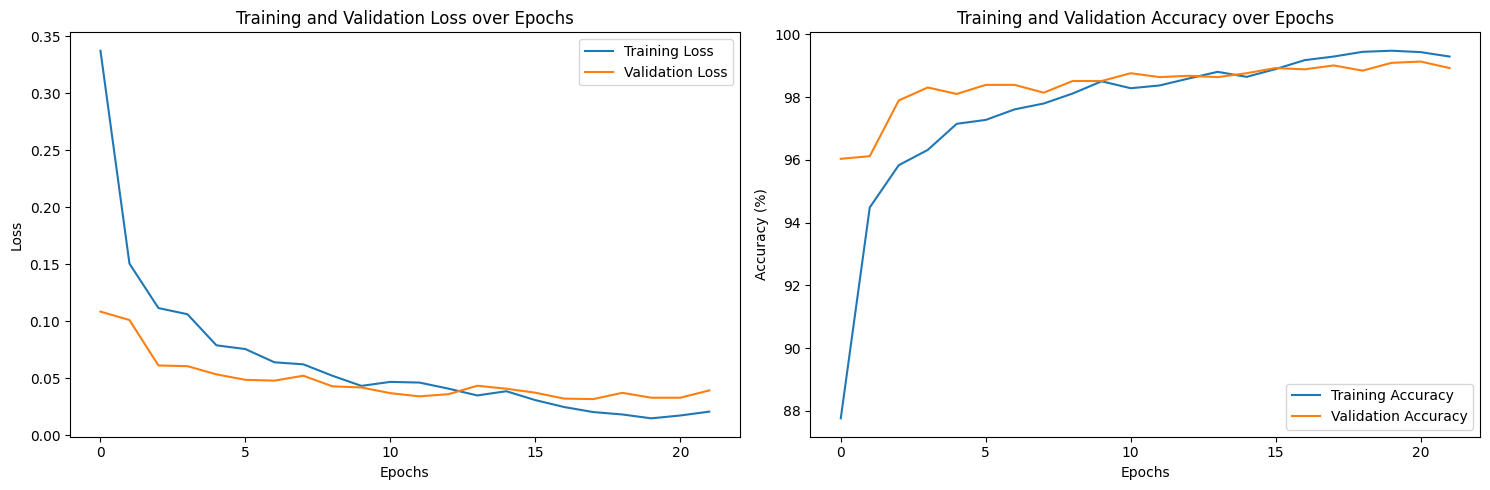

Grafik disimpan sebagai training_curves.png


In [9]:
total_loss_train_plot      = []
total_loss_validation_plot = []
total_acc_train_plot       = []
total_acc_validation_plot  = []

for epoch in range(EPOCHS):
    # ── TRAINING PHASE ──────────────────────────────────────────────
    model.train()  # PERBAIKAN: set mode train -> Dropout & BN aktif
    total_acc_train  = 0
    total_loss_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs    = model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()
        optimizer.step()

        train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
        total_acc_train += train_acc

    # ── VALIDATION PHASE ────────────────────────────────────────────
    model.eval()  # PERBAIKAN: set mode eval -> Dropout nonaktif, BN pakai running stats
    total_loss_val = 0
    total_acc_val  = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs  = model(inputs)
            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
            total_acc_val += val_acc

    # PERBAIKAN: Bagi dengan len(loader) bukan hardcoded 1000
    avg_train_loss = total_loss_train / len(train_loader)
    avg_val_loss   = total_loss_val   / len(val_loader)
    avg_train_acc  = (total_acc_train / len(train_dataset)) * 100
    avg_val_acc    = (total_acc_val   / len(val_dataset))   * 100

    total_loss_train_plot.append(round(avg_train_loss, 4))
    total_loss_validation_plot.append(round(avg_val_loss, 4))
    total_acc_train_plot.append(round(avg_train_acc, 4))
    total_acc_validation_plot.append(round(avg_val_acc, 4))

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} Acc: {avg_train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} Acc: {avg_val_acc:.2f}%")

    # PERBAIKAN: Step scheduler berdasarkan val_loss
    scheduler.step(avg_val_loss)

    # PERBAIKAN: Early stopping check
    early_stopping(avg_val_loss, model)
    if early_stopping.early_stop:
        print(f"\n🛑 Early Stopping triggered pada epoch {epoch+1}!")
        break

# Load model terbaik yang disimpan early stopping
model.load_state_dict(torch.load('best_model.pt'))
print("\n✅ Model terbaik berhasil di-load!")

model.eval()  # PERBAIKAN: set mode eval sebelum test

with torch.no_grad():
    total_loss_test = 0
    total_acc_test  = 0

    for inputs, labels in test_loader:
        predictions = model(inputs)
        acc = (torch.argmax(predictions, axis=1) == labels).sum().item()
        total_acc_test += acc
        test_loss = criterion(predictions, labels)
        total_loss_test += test_loss.item()

avg_test_loss = total_loss_test / len(test_loader)  # PERBAIKAN: bagi len(loader)
avg_test_acc  = (total_acc_test / len(test_dataset)) * 100

print(f"Test Accuracy : {avg_test_acc:.2f}%")
print(f"Test Loss     : {avg_test_loss:.4f}")

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot,      label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot,      label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Grafik disimpan sebagai training_curves.png")

##**7. Prediksi Gambar (Input dari User)**

**PERBAIKAN BESAR:** Fungsi `predict_image()` pada kode asli:
- Parameter `image_path` TIDAK digunakan sama sekali!
- Path gambar hardcoded ke `/content/cat.jpg` -> tidak bisa menerima input lain
- Tidak ada `model.eval()` sebelum prediksi -> Dropout masih aktif!

Kode baru:
- Parameter `image_path` benar-benar digunakan
- `model.eval()` dipanggil sebelum prediksi
- Ada fungsi interaktif untuk upload & prediksi dari Google Colab
- Menampilkan gambar + hasil prediksi secara visual

In [10]:
def predict_image(image_path):
    """
    Prediksi kelas hewan dari path gambar.

    Args:
        image_path (str): Path ke file gambar

    Returns:
        str: Nama kelas hewan yang diprediksi
    """
    # PERBAIKAN: set model ke eval mode agar Dropout nonaktif
    model.eval()

    # PERBAIKAN: Gunakan parameter image_path, bukan hardcoded
    image = Image.open(image_path).convert('RGB')

    # Tampilkan gambar input
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

    # Preprocessing menggunakan val_test_transform (tanpa augmentasi)
    image_tensor = val_test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)[0]  # Probabilitas tiap kelas
        predicted_idx = torch.argmax(probabilities).item()

    predicted_class = label_encoder.inverse_transform([predicted_idx])[0]
    confidence = probabilities[predicted_idx].item() * 100

    # Tampilkan semua probabilitas
    print("\n📊 Hasil Prediksi:")
    print("-" * 35)
    for i, class_name in enumerate(label_encoder.classes_):
        prob = probabilities[i].item() * 100
        bar  = "█" * int(prob / 5)
        marker = " ← PREDIKSI" if i == predicted_idx else ""
        print(f"  {class_name:10s}: {prob:6.2f}% {bar}{marker}")
    print("-" * 35)
    print(f"\n🐾 Hewan: {predicted_class.upper()} ({confidence:.1f}% confidence)")

    return predicted_class


print("Fungsi predict_image() siap digunakan!")

Fungsi predict_image() siap digunakan!


# **TESTING**

Silakan upload gambar hewan (cat, dog, atau wild)...


Saving WhatsApp Image 2026-04-09 at 14.07.24.jpeg to WhatsApp Image 2026-04-09 at 14.07.24.jpeg

File diupload: WhatsApp Image 2026-04-09 at 14.07.24.jpeg


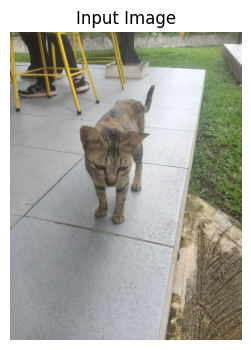


📊 Hasil Prediksi:
-----------------------------------
  cat       :  98.16% ███████████████████ ← PREDIKSI
  dog       :   1.63% 
  wild      :   0.21% 
-----------------------------------

🐾 Hewan: CAT (98.2% confidence)
Mengambil 6 gambar random dari test set...



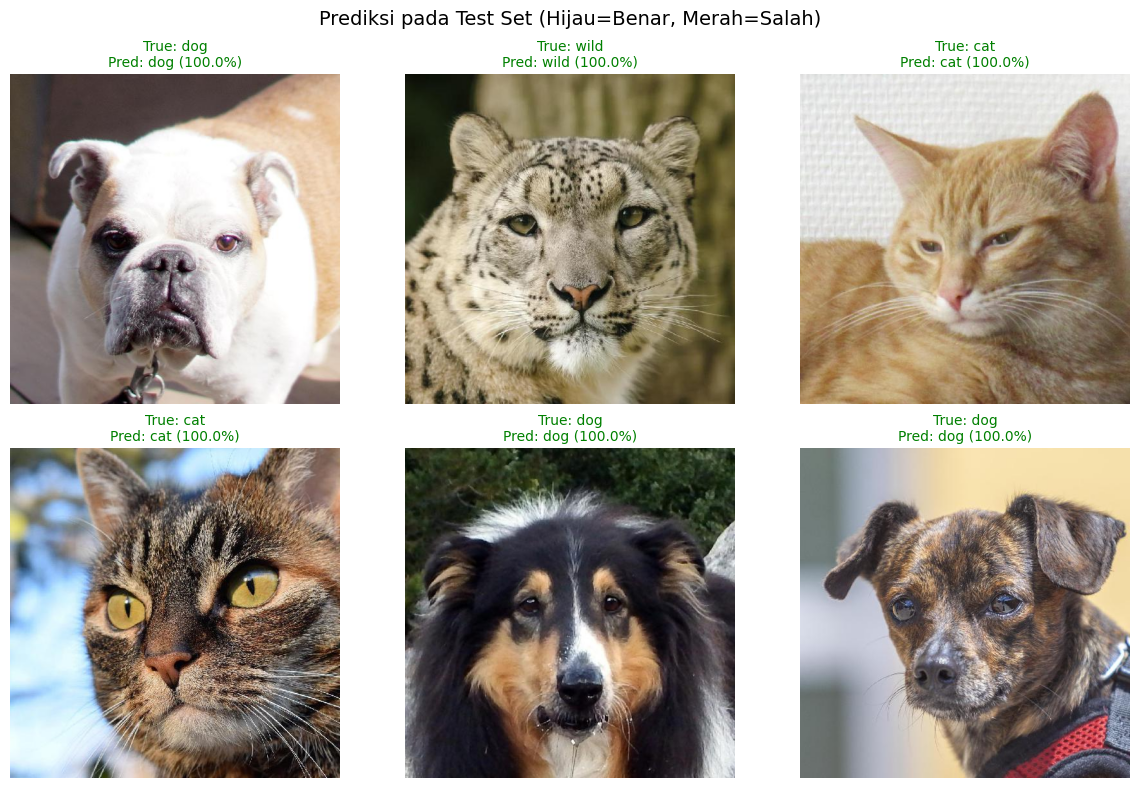

In [11]:
# ─── Cara 1: Upload gambar dari komputer lokal (Google Colab) ───────────────
from google.colab import files

print("Silakan upload gambar hewan (cat, dog, atau wild)...")
uploaded = files.upload()

if uploaded:
    for filename in uploaded.keys():
        print(f"\nFile diupload: {filename}")
        result = predict_image(filename)
else:
    print("Tidak ada file yang diupload.")

# ─── Cara 2: Prediksi gambar random dari test set ───────────────────────────
print("Mengambil 6 gambar random dari test set...\n")

sample_df = test.sample(n=6, random_state=99)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

model.eval()
for i, (_, row) in enumerate(sample_df.iterrows()):
    img_path    = row['image_path']
    true_label  = row['labels']

    image       = Image.open(img_path).convert('RGB')
    image_tensor = val_test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        pred_idx = torch.argmax(output, dim=1).item()
        pred_label = label_encoder.inverse_transform([pred_idx])[0]
        confidence = torch.softmax(output, dim=1)[0][pred_idx].item() * 100

    axes[i].imshow(image)
    axes[i].axis('off')

    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
        color=color, fontsize=10
    )

plt.suptitle('Prediksi pada Test Set (Hijau=Benar, Merah=Salah)', fontsize=14)
plt.tight_layout()
plt.show()

# **SAVE MODEL**

In [12]:
# Simpan model beserta label encoder dan transform
torch.save({
    'model_state_dict'  : model.state_dict(),
    'label_classes'     : label_encoder.classes_,
    'num_classes'       : num_classes,
}, 'animal_classifier_final.pt')

print("✅ Model disimpan sebagai: animal_classifier_final.pt")

# Download model ke komputer lokal (Google Colab)
from google.colab import files
files.download('animal_classifier_final.pt')
files.download('training_curves.png')

✅ Model disimpan sebagai: animal_classifier_final.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
!pip install onnx --quiet

import torch
import os, json

# ── 1. Load weights ──
checkpoint_path = 'best_model.pt'

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"❌ File '{checkpoint_path}' ga ada.")

state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

# ── 2. Cek weights ──
total_params = sum(p.numel() for p in model.parameters())
sample_weight = next(model.parameters()).data

print(f"✅ Total parameters : {total_params:,}")
print(f"   Weight mean      : {sample_weight.mean().item():.6f}")
print(f"   Weight std       : {sample_weight.std().item():.6f}")

if sample_weight.std().item() < 1e-6:
    raise ValueError("❌ Weights kosong / ga ke-load")

# ── 3. Forward test ──
dummy_input = torch.randn(1, 3, 128, 128).to(device)

with torch.no_grad():
    test_output = model(dummy_input)

print(f"✅ Forward OK — shape: {test_output.shape}")

# ── 4. Export ONNX pakai TorchScript trace (simpan bobot dengan benar) ──
export_path = "model.onnx"

# Trace dulu ke TorchScript
traced = torch.jit.trace(model, dummy_input)

# Export dari TorchScript — ini yang benar-benar menyimpan bobot
torch.onnx.export(
    traced,
    dummy_input,
    export_path,
    export_params=True,
    opset_version=11,           # opset 11 paling stabil & kompatibel
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input" : {0: "batch_size"},
        "output": {0: "batch_size"}
    },
    dynamo=False
)

# ── 5. Validasi ONNX ──
import onnx
onnx_model = onnx.load(export_path)
onnx.checker.check_model(onnx_model)
print("✅ ONNX model valid!")

# ── 6. Cek ukuran ──
size_bytes = os.path.getsize(export_path)
size_mb = size_bytes / (1024 * 1024)

print("✅ Export: " + export_path)
print(f"   Size: {size_mb:.2f} MB")

if size_mb < 1.0:
    print("⚠️  File masih kecil!")
else:
    print("   Ukuran normal ✓")

# ── 7. Kelas ──
classes = list(label_encoder.classes_)
print("📋 Classes: " + str(classes))
print("const CLASSES = " + json.dumps(classes) + ";")

# ── 8. Download ──
from google.colab import files
files.download(export_path)


✅ Total parameters : 8,845,571
   Weight mean      : -0.004802
   Weight std       : 0.112355
✅ Forward OK — shape: torch.Size([1, 3])


/tmp/ipykernel_13370/1327612050.py:42: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1508: UserWarning: no signature found for builtin <built-in method __call__ of pybind11_builtins.pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1 object at 0x7caa681594f0>, skipping _decide_input_format
  args = _decide_input_format(model, args)


✅ ONNX model valid!
✅ Export: model.onnx
   Size: 33.75 MB
   Ukuran normal ✓
📋 Classes: ['cat', 'dog', 'wild']
const CLASSES = ["cat", "dog", "wild"];


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>